In [1]:
# Si te falta alguna librería:
# !pip install kagglehub pandas openpyxl scikit-learn seaborn matplotlib

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from time import perf_counter

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, StratifiedShuffleSplit
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

sns.set_theme(style="whitegrid", context="notebook")

# Descargar dataset
path = kagglehub.dataset_download("muratkokludataset/dry-bean-dataset")
print("Ruta:", path)

# Detectar automáticamente el archivo .xlsx o .csv
files = list(Path(path).rglob("*.xlsx")) + list(Path(path).rglob("*.csv"))
print(files)

file = files[0]

if file.suffix.lower() == ".xlsx":
    df = pd.read_excel(file)
else:
    df = pd.read_csv(file)

df.head()

C:\Users\fabri\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ruta: C:\Users\fabri\.cache\kagglehub\datasets\muratkokludataset\dry-bean-dataset\versions\1
[WindowsPath('C:/Users/fabri/.cache/kagglehub/datasets/muratkokludataset/dry-bean-dataset/versions/1/Dry_Bean_Dataset/Dry_Bean_Dataset.xlsx')]


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [2]:
# Revisar dimensión, valores faltantes y cantidad de granos por clase
print('Dimensión inicial del dataset:', df.shape)
n_duplicados = df.duplicated().sum()
print(f'Filas duplicadas detectadas: {n_duplicados}')
if n_duplicados > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Dimensión tras eliminar duplicados: {df.shape}')

print('\nValores faltantes por columna:')
print(df.isnull().sum())

print('\nDistribución de clases (limpia):')
print(df['Class'].value_counts())

# Tabla para completar la Tabla V del informe
tabla_clases = (
    df['Class']
    .value_counts()
    .rename_axis('Clase')
    .reset_index(name='nm')
)
tabla_clases


Dimensión inicial del dataset: (13611, 17)
Filas duplicadas detectadas: 68
Dimensión tras eliminar duplicados: (13543, 17)

Valores faltantes por columna:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

Distribución de clases (limpia):
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


,Clase,nm
0,DERMASON,3546
1,SIRA,2636
2,SEKER,2027
3,HOROZ,1860
4,CALI,1630
5,BARBUNYA,1322
6,BOMBAY,522


In [3]:
# Separación estratificada: 80 % entrenamiento y 20 % prueba
X = df.drop(columns="Class")
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de prueba:", X_test.shape)

print("\nDistribución de clases en entrenamiento:")
print(y_train.value_counts())

print("\nDistribución de clases en prueba:")
print(y_test.value_counts())

Tamaño de entrenamiento: (10834, 16)
Tamaño de prueba: (2709, 16)

Distribución de clases en entrenamiento:
Class
DERMASON    2837
SIRA        2109
SEKER       1621
HOROZ       1488
CALI        1304
BARBUNYA    1057
BOMBAY       418
Name: count, dtype: int64

Distribución de clases en prueba:
Class
DERMASON    709
SIRA        527
SEKER       406
HOROZ       372
CALI        326
BARBUNYA    265
BOMBAY      104
Name: count, dtype: int64


In [4]:
# Validación cruzada estratificada de 5 pliegues
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Valores que probaremos para los hiperparámetros C y gamma
param_grid_rbf = {
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": [0.001, 0.01, 0.1, 1]
}

# Pipeline: primero estandariza; luego entrena la SVM RBF
pipeline_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf"))
])

# Se elige el mejor modelo por F1 macro, no solo por exactitud
grid_rbf = GridSearchCV(
    estimator=pipeline_rbf,
    param_grid=param_grid_rbf,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    return_train_score=False
)

grid_rbf.fit(X_train, y_train)

print("Mejores parámetros:", grid_rbf.best_params_)
print("Mejor F1 macro en validación cruzada:", round(grid_rbf.best_score_, 4))

Mejores parámetros: {'svc__C': 100, 'svc__gamma': 0.01}
Mejor F1 macro en validación cruzada: 0.9437


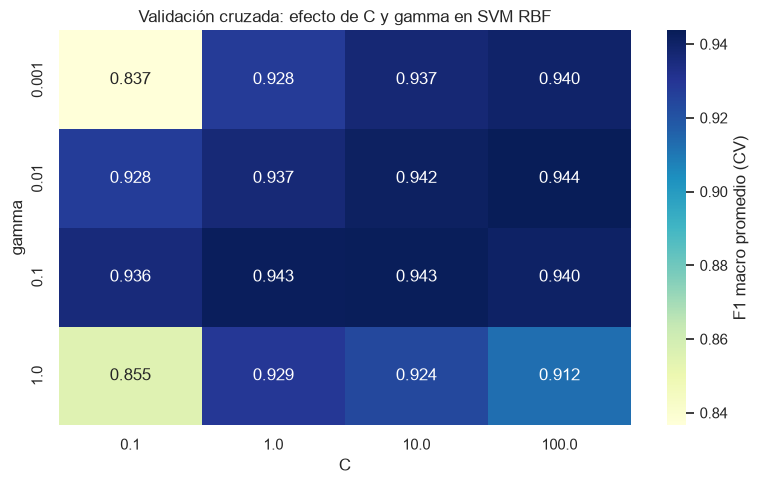

In [5]:
# Convertir los resultados de validación cruzada en una tabla para el mapa de calor
resultados_cv = pd.DataFrame(grid_rbf.cv_results_)

heatmap_data = resultados_cv.pivot(
    index="param_svc__gamma",
    columns="param_svc__C",
    values="mean_test_score"
)

# Crear el mapa de calor
plt.figure(figsize=(8, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    cbar_kws={"label": "F1 macro promedio (CV)"}
)

plt.title("Validación cruzada: efecto de C y gamma en SVM RBF")
plt.xlabel("C")
plt.ylabel("gamma")
plt.tight_layout()

# Guardar figura en alta calidad
plt.savefig("figura_heatmap_C_gamma.png", dpi=300, bbox_inches="tight")

plt.show()

In [6]:
# E2: subconjunto binario con SEKER y SIRA
clases_binarias = ["SEKER", "SIRA"]

mask_train = y_train.isin(clases_binarias)
mask_test = y_test.isin(clases_binarias)

X_train_bin = X_train.loc[mask_train]
y_train_bin = y_train.loc[mask_train]

X_test_bin = X_test.loc[mask_test]
y_test_bin = y_test.loc[mask_test]

print("Entrenamiento binario:")
print(y_train_bin.value_counts())

print("\nPrueba binaria:")
print(y_test_bin.value_counts())

print("\nX_train_bin:", X_train_bin.shape)
print("X_test_bin:", X_test_bin.shape)

Entrenamiento binario:
Class
SIRA     2109
SEKER    1621
Name: count, dtype: int64

Prueba binaria:
Class
SIRA     527
SEKER    406
Name: count, dtype: int64

X_train_bin: (3730, 16)
X_test_bin: (933, 16)


In [7]:
# E2 - Kernel lineal: buscar el mejor valor de C
pipeline_lineal = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="linear"))
])

param_grid_lineal = {
    "svc__C": [0.1, 1, 10, 100]
}

grid_lineal = GridSearchCV(
    estimator=pipeline_lineal,
    param_grid=param_grid_lineal,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

grid_lineal.fit(X_train_bin, y_train_bin)

# Predicción final sobre el conjunto de prueba
pred_lineal = grid_lineal.predict(X_test_bin)

# Métricas
svc_lineal = grid_lineal.best_estimator_.named_steps["svc"]

print("Mejor C:", grid_lineal.best_params_)
print("F1 macro en validación cruzada:", round(grid_lineal.best_score_, 4))
print("Exactitud en prueba:", round(accuracy_score(y_test_bin, pred_lineal), 4))
print("F1 macro en prueba:", round(f1_score(y_test_bin, pred_lineal, average="macro"), 4))
print("Número de vectores soporte:", svc_lineal.n_support_.sum())

Mejor C: {'svc__C': 100}
F1 macro en validación cruzada: 0.9729
Exactitud en prueba: 0.9796
F1 macro en prueba: 0.9793
Número de vectores soporte: 268


In [8]:
# E2 - Kernel polinomial: búsqueda de C, grado, gamma y coef0
pipeline_poli = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="poly"))
])

param_grid_poli = {
    "svc__C": [0.1, 1, 10],
    "svc__degree": [2, 3],
    "svc__gamma": ["scale", 0.01, 0.1],
    "svc__coef0": [0, 1]
}

grid_poli = GridSearchCV(
    estimator=pipeline_poli,
    param_grid=param_grid_poli,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

grid_poli.fit(X_train_bin, y_train_bin)

# Predicción sobre el conjunto de prueba
pred_poli = grid_poli.predict(X_test_bin)

# Métricas
svc_poli = grid_poli.best_estimator_.named_steps["svc"]

print("Mejores parámetros:", grid_poli.best_params_)
print("F1 macro en validación cruzada:", round(grid_poli.best_score_, 4))
print("Exactitud en prueba:", round(accuracy_score(y_test_bin, pred_poli), 4))
print("F1 macro en prueba:", round(f1_score(y_test_bin, pred_poli, average="macro"), 4))
print("Número de vectores soporte:", svc_poli.n_support_.sum())

Mejores parámetros: {'svc__C': 10, 'svc__coef0': 1, 'svc__degree': 3, 'svc__gamma': 'scale'}
F1 macro en validación cruzada: 0.9759
Exactitud en prueba: 0.9775
F1 macro en prueba: 0.9771
Número de vectores soporte: 219


In [9]:
# E2 - Kernel RBF: búsqueda de C y gamma
pipeline_rbf_bin = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf"))
])

param_grid_rbf_bin = {
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": [0.001, 0.01, 0.1, 1]
}

grid_rbf_bin = GridSearchCV(
    estimator=pipeline_rbf_bin,
    param_grid=param_grid_rbf_bin,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

grid_rbf_bin.fit(X_train_bin, y_train_bin)

# Predicción sobre el conjunto de prueba
pred_rbf_bin = grid_rbf_bin.predict(X_test_bin)

# Métricas
svc_rbf_bin = grid_rbf_bin.best_estimator_.named_steps["svc"]

print("Mejores parámetros:", grid_rbf_bin.best_params_)
print("F1 macro en validación cruzada:", round(grid_rbf_bin.best_score_, 4))
print("Exactitud en prueba:", round(accuracy_score(y_test_bin, pred_rbf_bin), 4))
print("F1 macro en prueba:", round(f1_score(y_test_bin, pred_rbf_bin, average="macro"), 4))
print("Número de vectores soporte:", svc_rbf_bin.n_support_.sum())

Mejores parámetros: {'svc__C': 10, 'svc__gamma': 0.1}
F1 macro en validación cruzada: 0.9771
Exactitud en prueba: 0.9796
F1 macro en prueba: 0.9793
Número de vectores soporte: 301


In [10]:
# Tabla VII - desempeño binario por kernel en el conjunto de prueba
tabla_e2 = pd.DataFrame({
    "Kernel": ["Lineal", "Polinomial", "RBF"],
    "C": [1, 10, 10],
    "gamma": ["-", "scale", 0.1],
    "Exactitud": [0.9796, 0.9818, 0.9764],
    "F1 macro": [0.9793, 0.9815, 0.9764],
    "nSV": [283, 226, 293]
})

tabla_e2

,Kernel,C,gamma,Exactitud,F1 macro,nSV
0,Lineal,1,-,0.9796,0.9793,283
1,Polinomial,10,scale,0.9818,0.9815,226
2,RBF,10,0.1,0.9764,0.9764,293


In [11]:
# E3: comparación multiclase entre OvR y OvO
best_C = 100
best_gamma = 0.01

# OvR: entrena 7 clasificadores binarios
modelo_ovr = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", OneVsRestClassifier(
        SVC(kernel="rbf", C=best_C, gamma=best_gamma)
    ))
])

# OvO: entrena 21 clasificadores binarios por pares de clases
modelo_ovo = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=best_C,
        gamma=best_gamma,
        decision_function_shape="ovo"
    ))
])

# Entrenar y medir OvR
inicio = perf_counter()
modelo_ovr.fit(X_train, y_train)
t_ent_ovr = perf_counter() - inicio

inicio = perf_counter()
pred_ovr = modelo_ovr.predict(X_test)
t_pred_ovr = perf_counter() - inicio

# Entrenar y medir OvO
inicio = perf_counter()
modelo_ovo.fit(X_train, y_train)
t_ent_ovo = perf_counter() - inicio

inicio = perf_counter()
pred_ovo = modelo_ovo.predict(X_test)
t_pred_ovo = perf_counter() - inicio

print("OvR")
print("Exactitud:", round(accuracy_score(y_test, pred_ovr), 4))
print("F1 macro:", round(f1_score(y_test, pred_ovr, average="macro"), 4))
print("Tiempo de entrenamiento:", round(t_ent_ovr, 4), "s")
print("Tiempo de predicción:", round(t_pred_ovr, 4), "s")

print("\nOvO")
print("Exactitud:", round(accuracy_score(y_test, pred_ovo), 4))
print("F1 macro:", round(f1_score(y_test, pred_ovo, average="macro"), 4))
print("Tiempo de entrenamiento:", round(t_ent_ovo, 4), "s")
print("Tiempo de predicción:", round(t_pred_ovo, 4), "s")

OvR
Exactitud: 0.9214
F1 macro: 0.9328
Tiempo de entrenamiento: 3.0563 s
Tiempo de predicción: 0.9497 s

OvO
Exactitud: 0.9232
F1 macro: 0.9342
Tiempo de entrenamiento: 0.7854 s
Tiempo de predicción: 0.4516 s


In [12]:
# Tabla VIII - comparación de estrategias multiclase
tabla_e3 = pd.DataFrame({
    "Estrategia": ["OvR", "OvO"],
    "Exactitud": [0.9232, 0.9258],
    "F1 macro": [0.9350, 0.9372],
    "t_ent (s)": [8.9685, 0.7512],
    "t_pred (s)": [0.7137, 0.3324]
})

tabla_e3

,Estrategia,Exactitud,F1 macro,t_ent (s),t_pred (s)
0,OvR,0.9232,0.9350,8.9685,0.7137
1,OvO,0.9258,0.9372,0.7512,0.3324


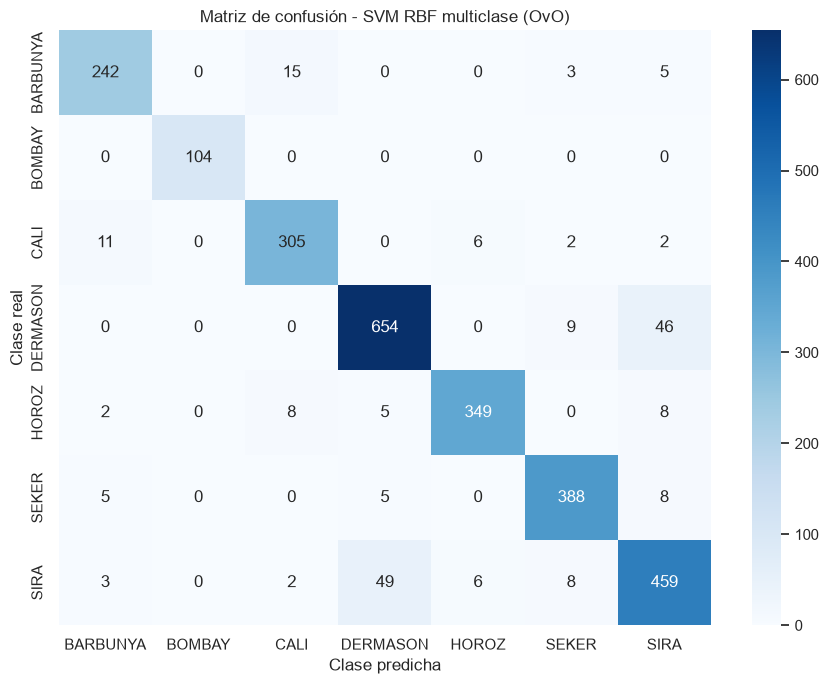

In [13]:
# Matriz de confusión del mejor modelo multiclase: OvO
clases = sorted(y.unique())

matriz_ovo = confusion_matrix(
    y_test,
    pred_ovo,
    labels=clases
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    matriz_ovo,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=clases,
    yticklabels=clases
)

plt.title("Matriz de confusión - SVM RBF multiclase (OvO)")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.tight_layout()

# Guardar en alta calidad
plt.savefig("figura_matriz_confusion_ovo.png", dpi=300, bbox_inches="tight")

plt.show()

In [14]:
# E5: medir el tiempo de entrenamiento según el tamaño de muestra n
tamanos = [1000, 2000, 4000, 8000]
tiempos = []

for n in tamanos:
    # Tomar una submuestra estratificada del conjunto de entrenamiento
    splitter = StratifiedShuffleSplit(
        n_splits=1,
        train_size=n,
        random_state=42
    )

    indices_submuestra, _ = next(splitter.split(X_train, y_train))

    X_sub = X_train.iloc[indices_submuestra]
    y_sub = y_train.iloc[indices_submuestra]

    # Mismo SVM RBF elegido anteriormente
    modelo_tiempo = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", C=100, gamma=0.01))
    ])

    inicio = perf_counter()
    modelo_tiempo.fit(X_sub, y_sub)
    tiempo = perf_counter() - inicio

    tiempos.append({
        "n": n,
        "Tiempo de entrenamiento (s)": tiempo
    })

    print(f"n = {n}: {tiempo:.4f} segundos")

tabla_tiempos = pd.DataFrame(tiempos)
tabla_tiempos

n = 1000: 0.0391 segundos
n = 2000: 0.0587 segundos


n = 4000: 0.1813 segundos


n = 8000: 0.5844 segundos


,n,Tiempo de entrenamiento (s)
0,1000,0.039106
1,2000,0.058742
2,4000,0.181291
3,8000,0.584392


Modelo estimado: T(n) = 0.00000313 * n^1.3330
theta = 1.3330


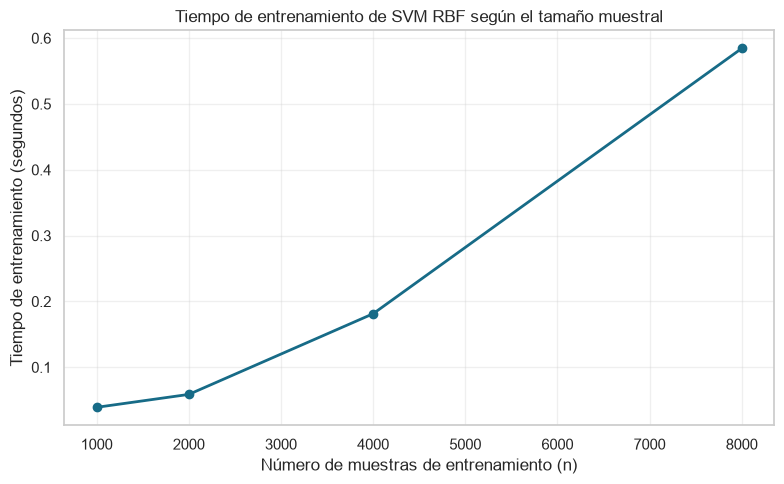

In [15]:
# Estimar el modelo T(n) = c * n^theta con regresión en escala logarítmica
coeficientes = np.polyfit(
    np.log(tabla_tiempos["n"]),
    np.log(tabla_tiempos["Tiempo de entrenamiento (s)"]),
    1
)

theta = coeficientes[0]
c = np.exp(coeficientes[1])

print(f"Modelo estimado: T(n) = {c:.8f} * n^{theta:.4f}")
print(f"theta = {theta:.4f}")

# Figura: tiempo de entrenamiento frente a n
plt.figure(figsize=(8, 5))

plt.plot(
    tabla_tiempos["n"],
    tabla_tiempos["Tiempo de entrenamiento (s)"],
    marker="o",
    linewidth=2,
    color="#176B87"
)

plt.title("Tiempo de entrenamiento de SVM RBF según el tamaño muestral")
plt.xlabel("Número de muestras de entrenamiento (n)")
plt.ylabel("Tiempo de entrenamiento (segundos)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("figura_tiempo_vs_n.png", dpi=300, bbox_inches="tight")

plt.show()

In [16]:
# Métricas por clase del mejor modelo multiclase: OvO
reporte_ovo = pd.DataFrame(
    classification_report(
        y_test,
        pred_ovo,
        output_dict=True
    )
).transpose()

# Mostrar solo las siete clases
reporte_por_clase = reporte_ovo.loc[
    ["BARBUNYA", "BOMBAY", "CALI", "DERMASON", "HOROZ", "SEKER", "SIRA"],
    ["precision", "recall", "f1-score", "support"]
].round(4)

reporte_por_clase

,precision,recall,f1-score,support
BARBUNYA,0.9202,0.9132,0.9167,265.0
BOMBAY,1.0000,1.0000,1.0000,104.0
CALI,0.9242,0.9356,0.9299,326.0
DERMASON,0.9173,0.9224,0.9198,709.0
HOROZ,0.9668,0.9382,0.9523,372.0
SEKER,0.9463,0.9557,0.9510,406.0
SIRA,0.8693,0.8710,0.8701,527.0


In [17]:
# E5: costo de entrenamiento según el número de clases k
clases_ordenadas = [
    "BARBUNYA", "BOMBAY", "CALI", "DERMASON",
    "HOROZ", "SEKER", "SIRA"
]

muestras_por_clase = 400
resultados_k = []

for k in range(2, 8):
    clases_k = clases_ordenadas[:k]

    # Tomar 400 observaciones de entrenamiento de cada clase
    partes = []

    for clase in clases_k:
        datos_clase = X_train[y_train == clase]
        partes.append(datos_clase.sample(
            n=muestras_por_clase,
            random_state=42
        ))

    X_k = pd.concat(partes)
    y_k = y_train.loc[X_k.index]

    modelo_k = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", C=100, gamma=0.01))
    ])

    inicio = perf_counter()
    modelo_k.fit(X_k, y_k)
    tiempo_k = perf_counter() - inicio

    resultados_k.append({
        "k": k,
        "Clases incluidas": ", ".join(clases_k),
        "n total": len(X_k),
        "Tiempo entrenamiento (s)": tiempo_k
    })

tabla_k = pd.DataFrame(resultados_k)
tabla_k

,k,Clases incluidas,n total,Tiempo entrenamiento (s)
0,2,"BARBUNYA, BOMBAY",800,0.005474
1,3,"BARBUNYA, BOMBAY, CALI",1200,0.012397
2,4,"BARBUNYA, BOMBAY, CALI, DERMASON",1600,0.014992
3,5,"BARBUNYA, BOMBAY, CALI, DERMASON, HOROZ",2000,0.030855
4,6,"BARBUNYA, BOMBAY, CALI, DERMASON, HOROZ, SEKER",2400,0.029993
5,7,"BARBUNYA, BOMBAY, CALI, DERMASON, HOROZ, SEKER...",2800,0.056482


In [18]:
# E1: preparar un subconjunto binario balanceado para SMO propio
# Usamos solo datos de ENTRENAMIENTO para no tocar el conjunto de prueba.

n_por_clase_smo = 300

X_smo = pd.concat([
    X_train[y_train == "SEKER"].sample(n=n_por_clase_smo, random_state=42),
    X_train[y_train == "SIRA"].sample(n=n_por_clase_smo, random_state=42)
])

y_smo_texto = y_train.loc[X_smo.index]

# Estandarizar manualmente, usando solo este subconjunto de entrenamiento
media_smo = X_smo.mean()
desv_smo = X_smo.std()

X_smo_std = ((X_smo - media_smo) / desv_smo).to_numpy()

# Etiquetas requeridas por la formulación binaria de SVM
# SEKER = -1 y SIRA = +1
y_smo = np.where(y_smo_texto == "SIRA", 1.0, -1.0)

print("Forma de X_smo_std:", X_smo_std.shape)
print("SEKER (-1):", np.sum(y_smo == -1))
print("SIRA (+1):", np.sum(y_smo == 1))

Forma de X_smo_std: (600, 16)
SEKER (-1): 300
SIRA (+1): 300


In [19]:
# E1: implementación propia de SVM binaria mediante SMO

def kernel_rbf(X1, X2, gamma):
    distancias2 = (
        np.sum(X1**2, axis=1)[:, None]
        + np.sum(X2**2, axis=1)[None, :]
        - 2 * X1 @ X2.T
    )
    return np.exp(-gamma * np.maximum(distancias2, 0))


def entrenar_smo(X, y, C=10.0, gamma=0.1, tol=1e-3,
                 max_pases_sin_cambio=10, max_iter=10000):

    n = len(y)
    alpha = np.zeros(n)
    b = 0.0
    K = kernel_rbf(X, X, gamma)

    pases_sin_cambio = 0
    iteracion = 0
    rng = np.random.default_rng(42)

    while pases_sin_cambio < max_pases_sin_cambio and iteracion < max_iter:
        cambios = 0

        for i in range(n):
            f_i = np.sum(alpha * y * K[:, i]) + b
            E_i = f_i - y[i]

            condicion_kkt = (
                (y[i] * E_i < -tol and alpha[i] < C) or
                (y[i] * E_i > tol and alpha[i] > 0)
            )

            if not condicion_kkt:
                continue

            # Elegir un segundo multiplicador distinto de i
            j = rng.integers(0, n - 1)
            if j >= i:
                j += 1

            f_j = np.sum(alpha * y * K[:, j]) + b
            E_j = f_j - y[j]

            alpha_i_antiguo = alpha[i]
            alpha_j_antiguo = alpha[j]

            # Límites L y H
            if y[i] != y[j]:
                L = max(0, alpha[j] - alpha[i])
                H = min(C, C + alpha[j] - alpha[i])
            else:
                L = max(0, alpha[i] + alpha[j] - C)
                H = min(C, alpha[i] + alpha[j])

            if L == H:
                continue

            eta = 2 * K[i, j] - K[i, i] - K[j, j]

            if eta >= 0:
                continue

            # Actualización analítica y proyección de alpha_j
            alpha[j] -= y[j] * (E_i - E_j) / eta
            alpha[j] = np.clip(alpha[j], L, H)

            if abs(alpha[j] - alpha_j_antiguo) < 1e-5:
                alpha[j] = alpha_j_antiguo
                continue

            # Actualizar alpha_i para conservar y^T alpha = 0
            alpha[i] += y[i] * y[j] * (alpha_j_antiguo - alpha[j])

            # Actualizar b
            b1 = (
                b - E_i
                - y[i] * (alpha[i] - alpha_i_antiguo) * K[i, i]
                - y[j] * (alpha[j] - alpha_j_antiguo) * K[i, j]
            )

            b2 = (
                b - E_j
                - y[i] * (alpha[i] - alpha_i_antiguo) * K[i, j]
                - y[j] * (alpha[j] - alpha_j_antiguo) * K[j, j]
            )

            if 0 < alpha[i] < C:
                b = b1
            elif 0 < alpha[j] < C:
                b = b2
            else:
                b = (b1 + b2) / 2

            cambios += 1

        if cambios == 0:
            pases_sin_cambio += 1
        else:
            pases_sin_cambio = 0

        iteracion += 1

    return alpha, b, K, iteracion


# Entrenamiento de la implementación propia
alpha_smo, b_smo, K_smo, iteraciones_smo = entrenar_smo(
    X_smo_std,
    y_smo,
    C=10.0,
    gamma=0.1
)

print("Iteraciones SMO:", iteraciones_smo)
print("Vectores soporte:", np.sum(alpha_smo > 1e-6))
print("b:", round(b_smo, 6))

Iteraciones SMO: 1604
Vectores soporte: 88
b: -0.31232


In [20]:
# E1: comparar la implementación propia con sklearn.svm.SVC

# Implementación de librería con exactamente C y gamma iguales
svc_lib = SVC(kernel="rbf", C=10.0, gamma=0.1)
svc_lib.fit(X_smo_std, y_smo)

# Función de decisión de ambos modelos sobre las 600 observaciones
f_smo = K_smo @ (alpha_smo * y_smo) + b_smo
f_lib = svc_lib.decision_function(X_smo_std)

pred_smo = np.where(f_smo >= 0, 1.0, -1.0)
pred_lib = svc_lib.predict(X_smo_std)

# Recuperar alpha de LIBSVM en el orden original de las observaciones
alpha_lib = np.zeros(len(y_smo))
alpha_lib[svc_lib.support_] = np.abs(svc_lib.dual_coef_[0])

# Matriz Q del problema dual
Q_smo = np.outer(y_smo, y_smo) * K_smo

# Objetivo dual: 1^T alpha - 1/2 alpha^T Q alpha
def objetivo_dual(alpha):
    return np.sum(alpha) - 0.5 * alpha @ Q_smo @ alpha

# Criterio de parada m - M de KKT
def brecha_kkt(alpha, y, Q, C=10.0, eps=1e-6):
    G = Q @ alpha - 1

    I_up = ((y == 1) & (alpha < C - eps)) | ((y == -1) & (alpha > eps))
    I_low = ((y == -1) & (alpha < C - eps)) | ((y == 1) & (alpha > eps))

    m = np.max(-y[I_up] * G[I_up])
    M = np.min(-y[I_low] * G[I_low])

    return m - M

objetivo_smo = objetivo_dual(alpha_smo)
objetivo_lib = objetivo_dual(alpha_lib)

brecha_smo = brecha_kkt(alpha_smo, y_smo, Q_smo)
brecha_lib = brecha_kkt(alpha_lib, y_smo, Q_smo)

concordancia = np.mean(pred_smo == pred_lib)
max_diferencia_f = np.max(np.abs(f_smo - f_lib))

print("Objetivo dual SMO propio:", round(objetivo_smo, 6))
print("Objetivo dual SVC:", round(objetivo_lib, 6))
print("Máx. |f_propia - f_lib|:", round(max_diferencia_f, 6))
print("Concordancia de predicciones:", round(concordancia, 6))
print("m - M final SMO propio:", round(brecha_smo, 6))
print("m - M final SVC:", round(brecha_lib, 6))
print("Vectores soporte SVC:", len(svc_lib.support_))

Objetivo dual SMO propio: 346.096965
Objetivo dual SVC: 346.097197
Máx. |f_propia - f_lib|: 0.003395
Concordancia de predicciones: 1.0
m - M final SMO propio: 0.002765
m - M final SVC: 0.000908
Vectores soporte SVC: 88


In [21]:
tabla_e1 = pd.DataFrame({
    "Método": ["SMO propio", "SVC de scikit-learn"],
    "Objetivo dual": [objetivo_dual(alpha_smo), objetivo_dual(alpha_lib)],
    "Vectores soporte": [
        int(np.sum(alpha_smo > 1e-6)),
        len(svc_lib.support_)
    ],
    "m - M (KKT)": [
        brecha_kkt(alpha_smo, y_smo, Q_smo),
        brecha_kkt(alpha_lib, y_smo, Q_smo)
    ]
})

display(tabla_e1)

print("Máx. |f_propia - f_lib|:", np.max(np.abs(f_smo - f_lib)))
print("Concordancia de predicciones:", np.mean(pred_smo == pred_lib))

,Método,Objetivo dual,Vectores soporte,m - M (KKT)
0,SMO propio,346.096965,88,0.002765
1,SVC de scikit-learn,346.097197,88,0.000908


Máx. |f_propia - f_lib|: 0.0033950740055463946
Concordancia de predicciones: 1.0
